In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# S04 — Time, missingness and uncertainty change the evidence

Read the matching lesson before running. Predictions first; source facts, manufactured controls and interpretations are labeled separately. This is not a sports performance benchmark.

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
from dataclasses import asdict
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').exists())
sys.path.insert(0, str(ROOT / 'src'))
from shape_lab import sports_v8 as sport
from shape_lab.persistence import finite_bottleneck
spl, profiles = sport.load_sports(ROOT)
frames = np.array([r['frame'] for r in spl['records']])
times = sport.frame_times(frames, spl['sampling_rate'])
ball = sport.to_metres([r['ball'] for r in spl['records']], spl['xyz_unit'])
report_dir = ROOT / 'reports/v8/sports'
report_dir.mkdir(parents=True, exist_ok=True)
def save_report(stage, result):
    # Reports contain ordinary finite values; absent values are recorded explicitly.
    (report_dir / f'{stage}.json').write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Data:', len(frames), 'selected frames from one shot;', len(profiles), 'profiles from', profiles.player_id.nunique(), 'players')


Data: 12 selected frames from one shot; 12 profiles from 8 players


## Past-only estimate versus future-assisted interpolation

In [3]:
q=np.array([-.1,.5,1.5,5.])
held,index=sport.causal_hold([0,1,2],[10,20,30],q,.75)
assert index.tolist()==[-1,0,1,-1]
display(pd.DataFrame({'query':q,'past_only_value':held,'source_row':index}))
print('At 1.5, interpolation using time 2 would return 25, but it uses the future.')


,query,past_only_value,source_row
0,-0.1,NaN,-1
1,0.5,10.0,0
2,1.5,20.0,1
3,5.0,NaN,-1


At 1.5, interpolation using time 2 would return 25, but it uses the future.


## Estimate provenance on sparse actual source times

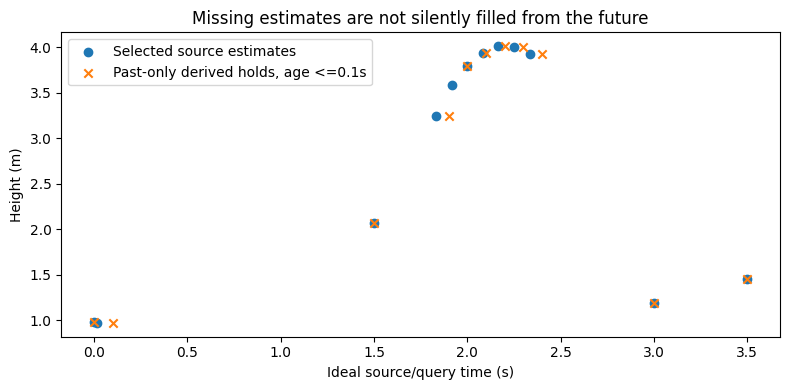

In [4]:
q=np.arange(0,3.6,.1)
held,index=sport.causal_hold(times,ball[:,2],q,max_age=.1)
fig,ax=plt.subplots(figsize=(8,4));ax.scatter(times,ball[:,2],label='Selected source estimates')
ax.scatter(q,held,marker='x',label='Past-only derived holds, age <=0.1s')
ax.set(xlabel='Ideal source/query time (s)',ylabel='Height (m)',title='Missing estimates are not silently filled from the future')
ax.legend();fig.tight_layout();plt.show()


## Known perturbation bound, not a measured noise distribution

In [5]:
rng=np.random.default_rng(808)
x=profiles[['running_distance_full_all','hsr_distance_full_all','sprint_distance_full_all']].to_numpy()
x,_,_=sport.fit_standardize(x,np.arange(len(x)))
base=sport.cloud_diagrams(x)[1]
trials=[]
for repeat in range(20):
    y=x+rng.normal(0,.01,x.shape) # Artificial error in dimensionless profile coordinates
    delta=float(np.linalg.norm(y-x,axis=1).max())
    distance=finite_bottleneck(base,sport.cloud_diagrams(y)[1])
    assert distance<=2*delta+1e-9
    trials.append({'delta':delta,'bottleneck_h1':float(distance),'bound':2*delta})
save_report('S04',{'perturbation_checks':trials,'accepted_query_count':int((index>=0).sum()),'total_queries':len(q),'perturbations_are_measured_sensor_noise':False})
print('20 matched-cloud checks passed. This is not a camera-error calibration.')


20 matched-cloud checks passed. This is not a camera-error calibration.


## Independent explanation
State the observation unit, assumptions, units, one result and one unsupported conclusion. Then work the separate learner notebook without the answer notebook open.